/var/folders/gd/9mzhm55x2774_fms0y2hrj800000gn/T/ipykernel_34228/1310517429.py:71: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  ball.set_data(x1[frame, 0], x1[frame, 1])


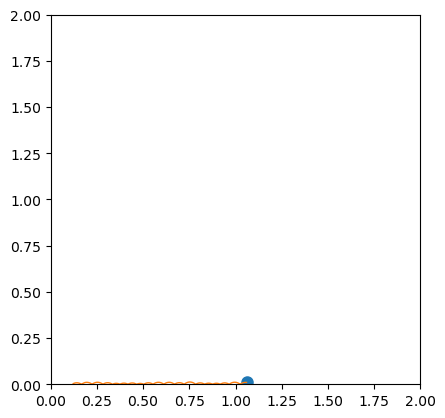

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter

m1 = 1
G = 1
g = -9.81
x0 = [0.5, 1]
v0 = [3, 3]

dt = 1/100
T = 1000

left_wall = 0
right_wall = 2
bot_wall = 0
top_wall = 2

e_loss = 0.77

# ---- simulate first (no plotting in the loop) ----
x1 = np.zeros((T + 1, 2), dtype=float)
v1 = np.zeros((T + 1, 2), dtype=float)
x1[0] = x0
v1[0] = v0

for i in range(T):
    x1_x = x1[i, 0] + v1[i, 0] * dt
    x1_y = x1[i, 1] + v1[i, 1] * dt + 0.5 * g * dt**2

    v1_x = v1[i, 0]
    v1_y = v1[i, 1] + g * dt

    if x1_x < left_wall:
        x1_x = 2 * left_wall - x1_x
        v1_x = -e_loss * v1_x
    elif x1_x > right_wall:
        x1_x = 2 * right_wall - x1_x
        v1_x = -e_loss * v1_x

    if x1_y > top_wall:
        x1_y = 2 * top_wall - x1_y
        v1_y = -e_loss * v1_y
    elif x1_y < bot_wall:
        x1_y = 2 * bot_wall - x1_y
        v1_y = -e_loss * v1_y

    x1[i + 1] = [x1_x, x1_y]
    v1[i + 1] = [v1_x, v1_y]

# ---- animate ----
fig, ax = plt.subplots()
ax.set_xlim(left_wall, right_wall)
ax.set_ylim(bot_wall, top_wall)
ax.set_aspect("equal", adjustable="box")

(ball,) = ax.plot([], [], marker="o", markersize=8, linestyle="None")
(trail,) = ax.plot([], [], linewidth=1)  # optional trail

# tweak these:
trail_len = 150          # how many previous points to show in the trail
interval_ms = 10         # speed of animation (ms between frames)

def init():
    ball.set_data([], [])
    trail.set_data([], [])
    return ball, trail

def update(frame):
    ball.set_data(x1[frame, 0], x1[frame, 1])

    start = max(0, frame - trail_len)
    trail.set_data(x1[start:frame+1, 0], x1[start:frame+1, 1])
    return ball, trail

ani = FuncAnimation(
    fig, update, frames=len(x1),
    init_func=init, blit=True, interval=interval_ms
)
ani.save("trajectory.gif", writer=PillowWriter(fps=60))
plt.show()